In [31]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 33.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [umap-learn]5 [numba]te]


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import f_classif, mutual_info_classif
import umap
from pandas.plotting import parallel_coordinates
import warnings

ModuleNotFoundError: No module named 'umap'

=== Binary Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(113), int64(15), object(1)
memory usage: 77.1+ MB
None
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459673   
...             ...            ...          ...            ...            ...   
relay4_log  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0       0.000000     0.000000   

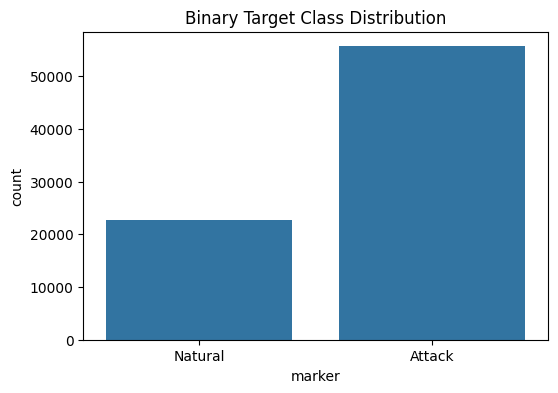

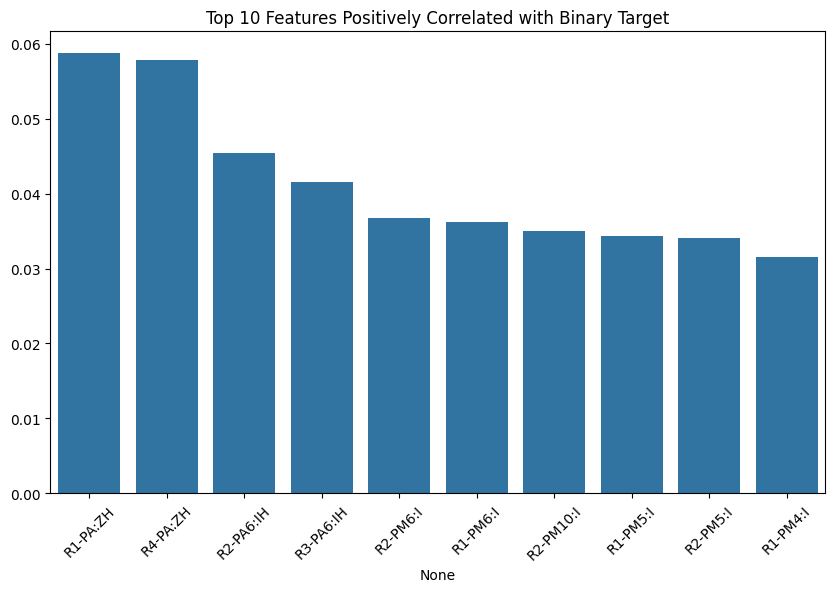

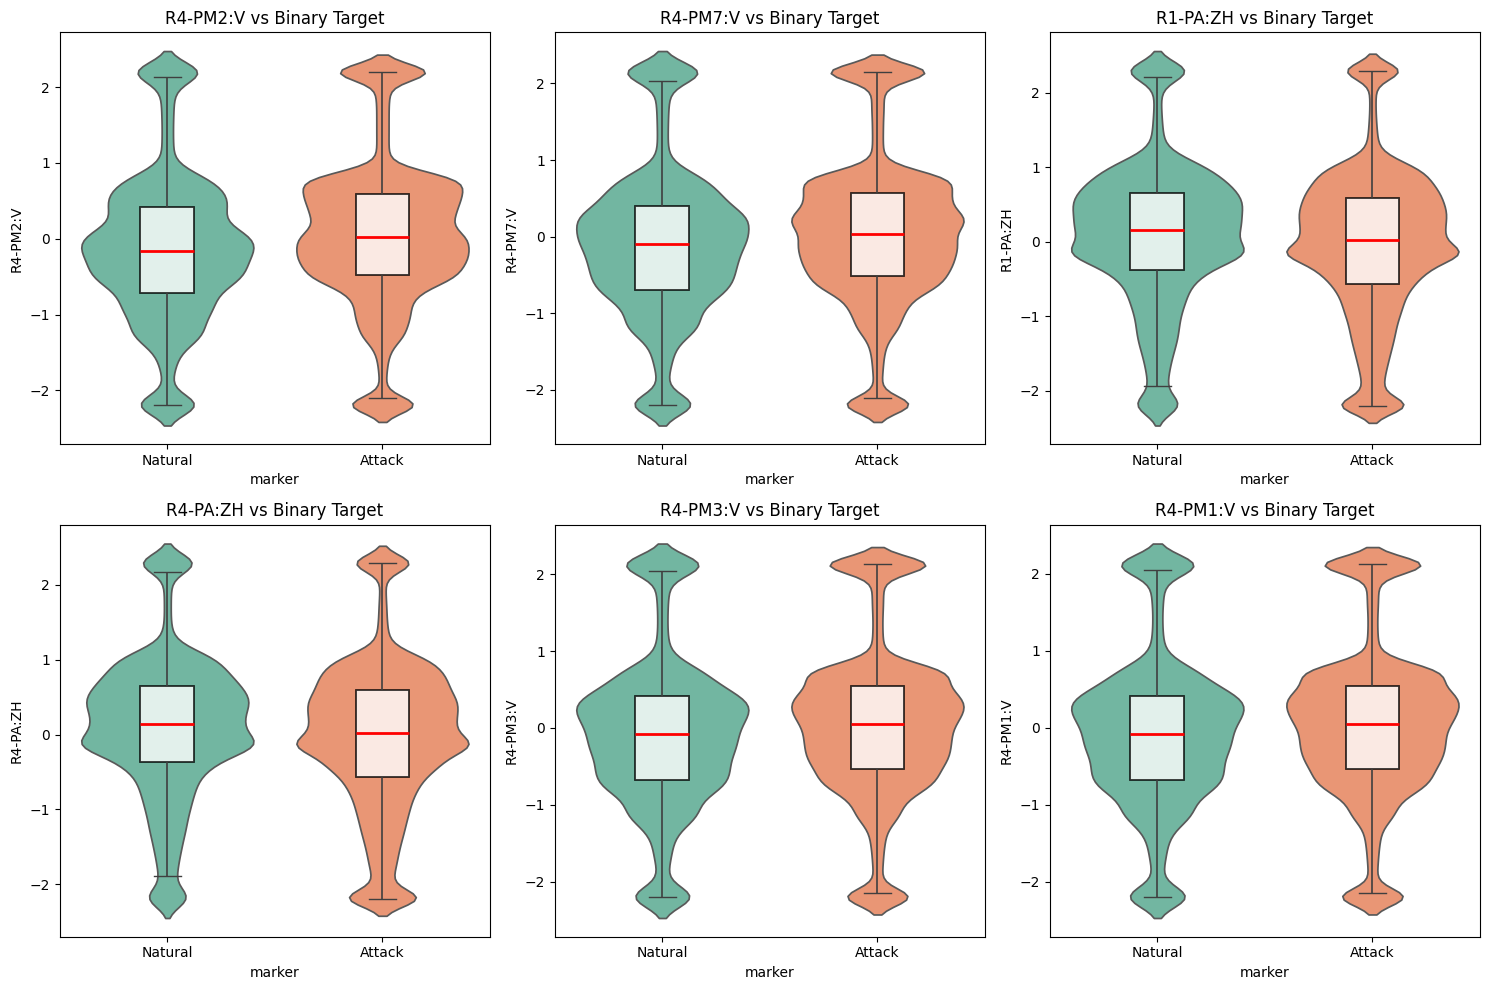

In [26]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Load dataset ---
binary_df = pd.read_csv("../data/merged/binary_dataset_clean.csv")
binary_df.columns = binary_df.columns.str.strip()

# --- Overview ---
print("=== Binary Dataset Overview ===")
print(binary_df.info())
print(binary_df.describe().T)

# --- Target ---
target_col = 'marker'
binary_df['target_num'] = binary_df[target_col].astype('category').cat.codes

# --- Standardize numeric features ---
numeric_cols = binary_df.select_dtypes(include='number').drop(columns=['target_num'])
scaler = StandardScaler()
binary_df[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
print("✅ Numeric features standardized (mean=0, std=1)")

# --- Class distribution ---
print("\n=== Class Distribution ===")
print(binary_df[target_col].value_counts())
print(binary_df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=binary_df)
plt.title("Binary Target Class Distribution")
plt.show()

# --- Correlation with target ---
corr_target = binary_df[numeric_cols.columns].corrwith(binary_df['target_num']).sort_values(ascending=False)

# Barplot of top 10 correlated features
plt.figure(figsize=(10,6))
sns.barplot(x=corr_target.head(10).index, y=corr_target.head(10).values)
plt.xticks(rotation=45)
plt.title("Top 10 Features Positively Correlated with Binary Target")
plt.show()

# Violin plots with thick boxplots (no warning)
top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    # Violin plot
    sns.violinplot(
        x=target_col,
        y=feat,
        hue=target_col,
        data=binary_df,
        ax=axes[i],
        inner=None,
        palette="Set2",
        legend=False
    )
    
    # Overlay boxplot
    sns.boxplot(
        x=target_col,
        y=feat,
        data=binary_df,
        ax=axes[i],
        width=0.25,
        showcaps=True,
        boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.3, 'alpha':0.8},
        whiskerprops={'linewidth':1.2},
        medianprops={'color':'red', 'linewidth':2},
        showfliers=False
    )
    
    axes[i].set_title(f"{feat} vs Binary Target")

plt.tight_layout()
plt.show()


Detected target column: marker
=== Three-Class Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 130 entries, R1-PA1:VH to target_num
dtypes: float64(113), int64(15), int8(1), object(1)
memory usage: 77.2+ MB
None
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459673   
...             ...            ...          ...            ...            ...   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0       0.000000     0.000000       0.000000       0.000000   
s

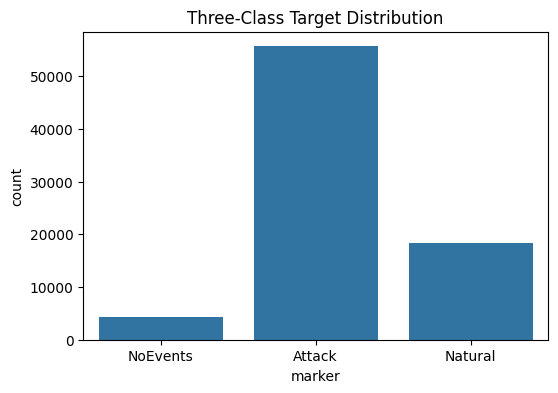

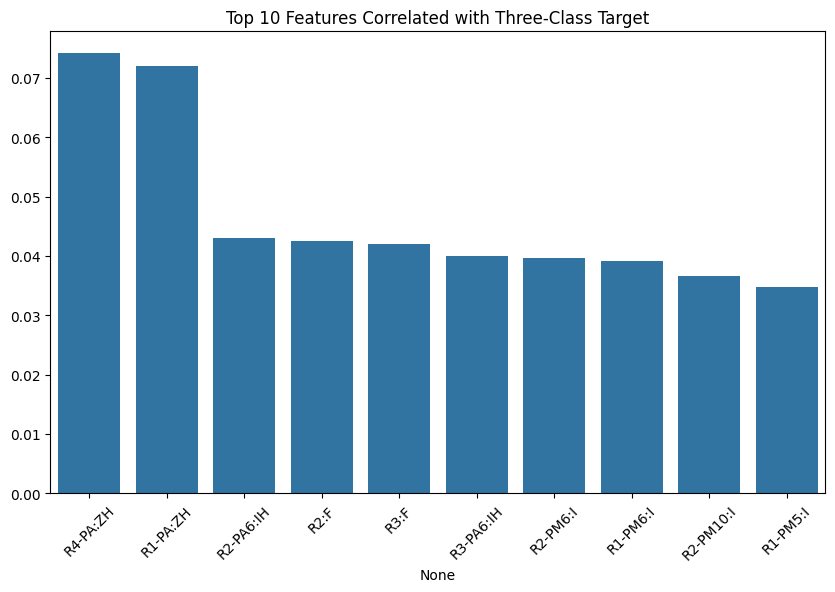

In [28]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Load dataset ---
three_class_df = pd.read_csv("../data/merged/three_class_dataset_clean.csv")
three_class_df.columns = three_class_df.columns.str.strip()

# --- Detect target column ---
possible_targets = [col for col in three_class_df.columns if 'target' in col.lower() or 'marker' in col.lower()]
if len(possible_targets) == 0:
    raise ValueError("No target column found in the dataset.")
target_col = possible_targets[0]
print(f"Detected target column: {target_col}")

# --- Encode target ---
three_class_df['target_num'] = three_class_df[target_col].astype('category').cat.codes

# --- Overview ---
print("=== Three-Class Dataset Overview ===")
print(three_class_df.info())
print(three_class_df.describe().T)

# --- Standardize numeric features ---
numeric_cols = three_class_df.select_dtypes(include='number').drop(columns=['target_num'])
scaler = StandardScaler()
three_class_df[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
print("✅ Numeric features standardized (mean=0, std=1)")

# --- Class distribution ---
print("\n=== Class Distribution ===")
print(three_class_df[target_col].value_counts())
print(three_class_df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=three_class_df)
plt.title("Three-Class Target Distribution")
plt.show()

# --- Correlation with target ---
corr_target = three_class_df[numeric_cols.columns].corrwith(three_class_df['target_num']).sort_values(ascending=False)

# Top 10 correlated features
plt.figure(figsize=(10,6))
sns.barplot(x=corr_target.head(10).index, y=corr_target.head(10).values)
plt.xticks(rotation=45)
plt.title("Top 10 Features Correlated with Three-Class Target")
plt.show()

=== Multi-Class Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(128), int64(1)
memory usage: 77.1 MB
None
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459674   
...             ...            ...          ...            ...            ...   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log3  78377.0       0.000000     0.000000       0.00

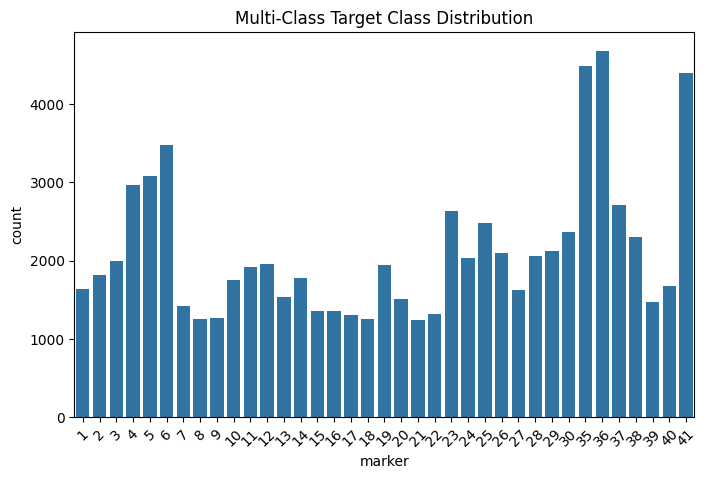

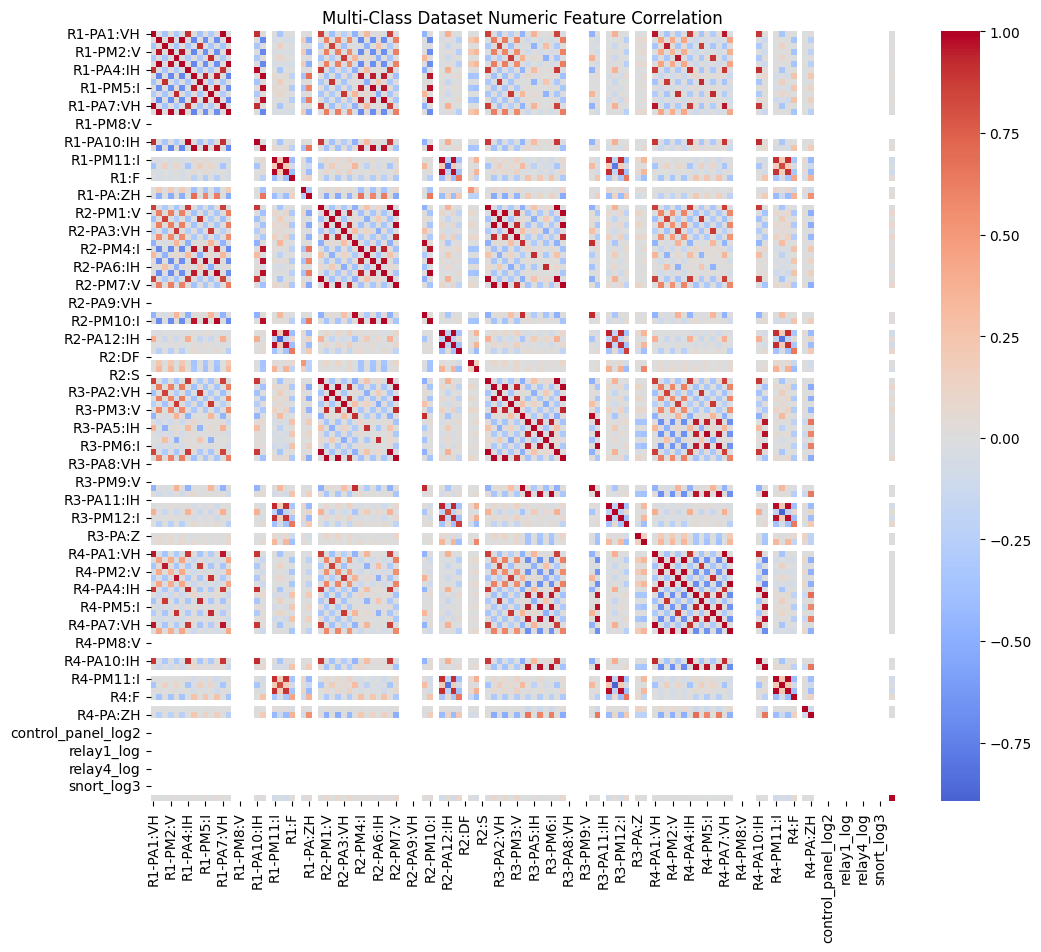

In [13]:
# --- Load cleaned CSV ---
multi_class_df = pd.read_csv("../data/merged/multi_class_dataset_clean.csv")
multi_class_df.columns = multi_class_df.columns.str.strip()

# --- Dataset overview ---
print("=== Multi-Class Dataset Overview ===")
print(multi_class_df.info())
print(multi_class_df.describe().T)

# --- Target column ---
target_col = 'marker'

# --- Class distribution ---
print("\n=== Class Distribution ===")
print(multi_class_df[target_col].value_counts())
print(multi_class_df[target_col].value_counts(normalize=True) * 100)

# --- Bar plot ---
plt.figure(figsize=(8,5))
sns.countplot(x=target_col, data=multi_class_df)
plt.title("Multi-Class Target Class Distribution")
plt.xticks(rotation=45)
plt.show()

# --- Correlation heatmap ---
numeric_cols = multi_class_df.select_dtypes(include='number')
numeric_cols = numeric_cols.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(12,10))
sns.heatmap(numeric_cols.fillna(0).corr(), cmap='coolwarm', center=0)
plt.title("Multi-Class Dataset Numeric Feature Correlation")
plt.show()



=== Binary Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(113), int64(15), object(1)
memory usage: 77.1+ MB
None

Descriptive Statistics:
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459673   
...             ...            ...          ...            ...            ...   
relay4_log  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0     

/tmp/ipykernel_14405/69220118.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


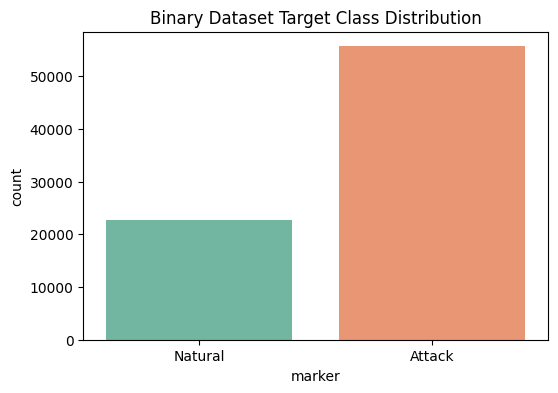


Top 10 Features Correlated with Target:
R1-PA:ZH     0.058694
R4-PA:ZH     0.057791
R2-PA6:IH    0.045472
R3-PA6:IH    0.041511
R2-PM6:I     0.036751
R1-PM6:I     0.036181
R2-PM10:I    0.034983
R1-PM5:I     0.034290
R2-PM5:I     0.034029
R1-PM4:I     0.031569
dtype: float64


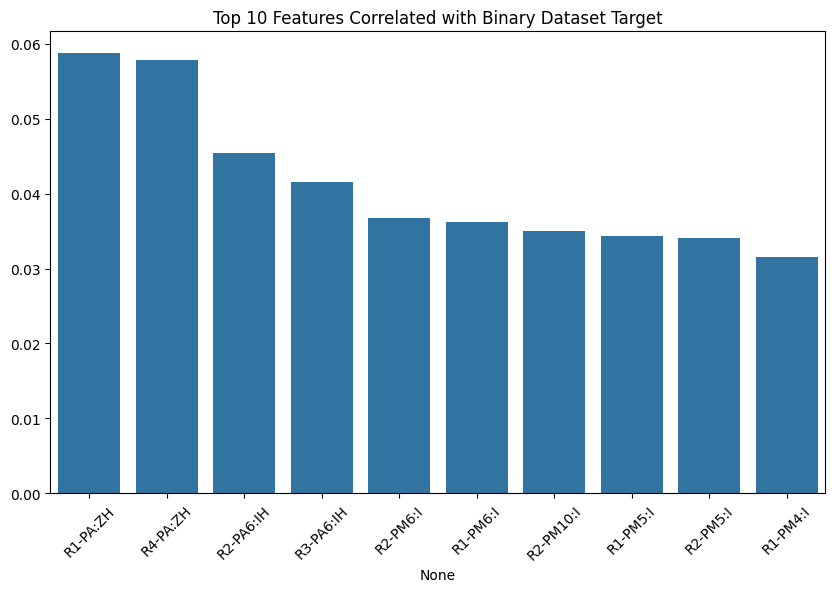

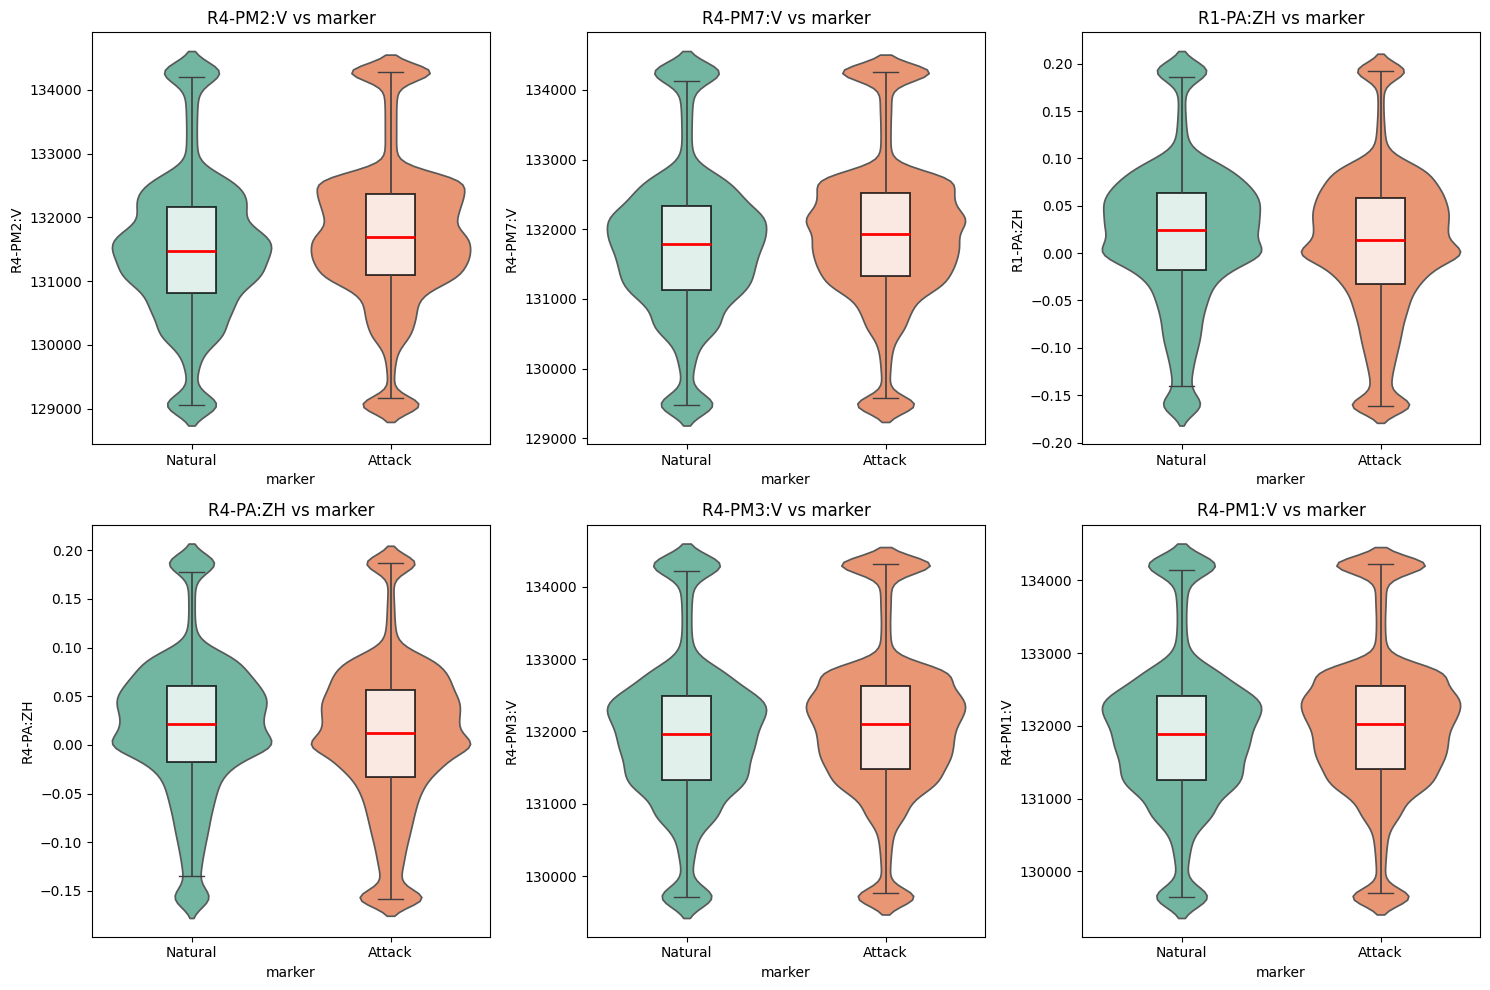


=== Binary Dataset Summary ===
Number of rows: 78377
Number of columns: 130
Target column: marker
Classes: ['Attack', 'Natural']
Top features correlated with target: ['R1-PA:ZH', 'R4-PA:ZH', 'R2-PA6:IH', 'R3-PA6:IH', 'R2-PM6:I', 'R1-PM6:I']
Next steps: feature selection, preprocessing, or model building.

=== Three-Class Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(113), int64(15), object(1)
memory usage: 77.1+ MB
None

Descriptive Statistics:
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315  

/tmp/ipykernel_14405/69220118.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


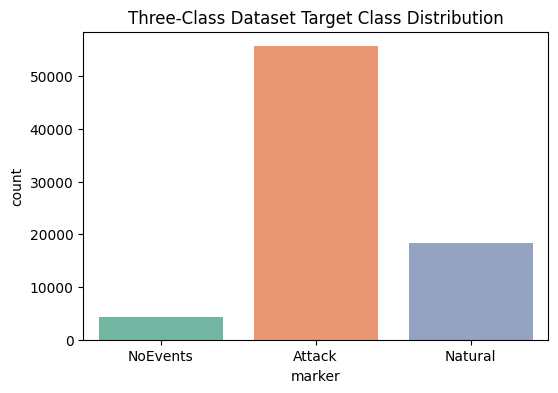


Top 10 Features Correlated with Target:
R4-PA:ZH     0.074149
R1-PA:ZH     0.072099
R2-PA6:IH    0.043002
R2:F         0.042544
R3:F         0.042073
R3-PA6:IH    0.040035
R2-PM6:I     0.039691
R1-PM6:I     0.039084
R2-PM10:I    0.036660
R1-PM5:I     0.034713
dtype: float64


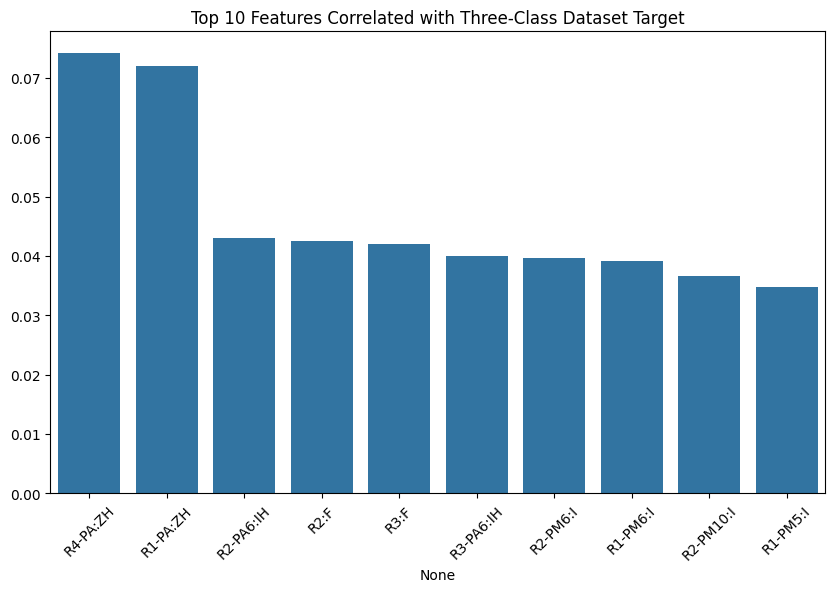

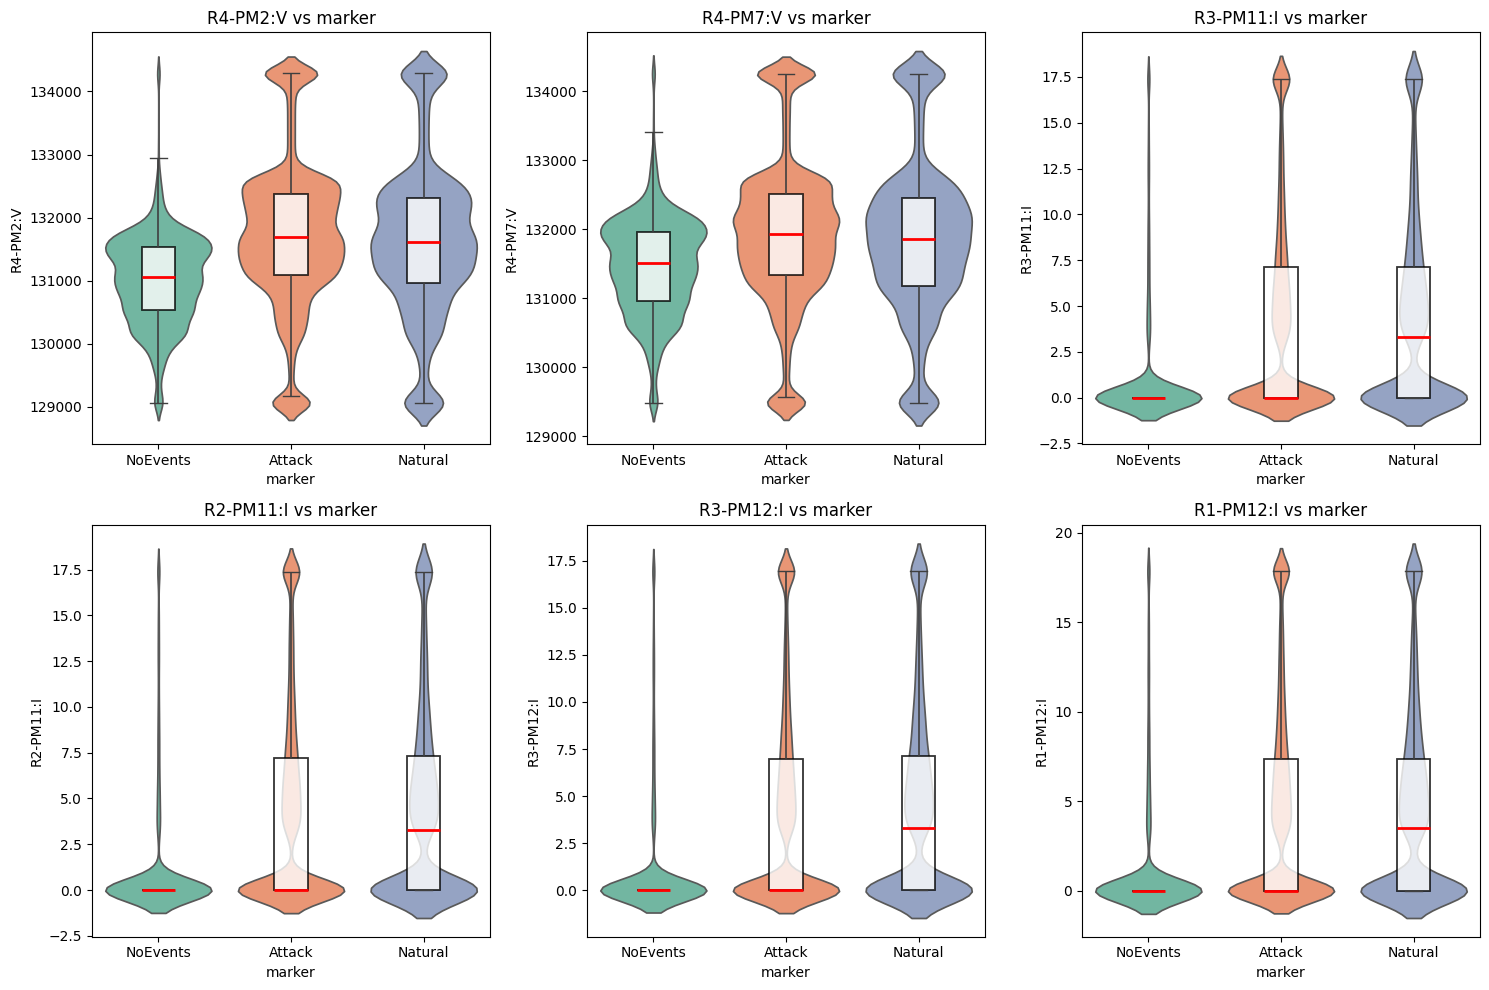


=== Three-Class Dataset Summary ===
Number of rows: 78377
Number of columns: 130
Target column: marker
Classes: ['Attack', 'Natural', 'NoEvents']
Top features correlated with target: ['R4-PA:ZH', 'R1-PA:ZH', 'R2-PA6:IH', 'R2:F', 'R3:F', 'R3-PA6:IH']
Next steps: feature selection, preprocessing, or model building.

=== Multi-Class Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 129 entries, R1-PA1:VH to marker
dtypes: float64(128), int64(1)
memory usage: 77.1 MB
None

Descriptive Statistics:
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97

/tmp/ipykernel_14405/69220118.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


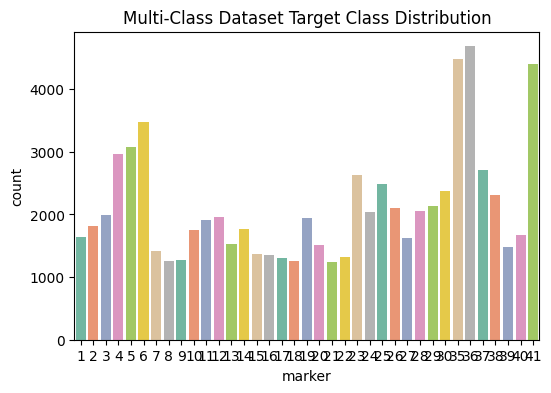


Top 10 Features Correlated with Target:
marker      0.995247
R3-PM3:V    0.092511
R2-PM3:V    0.086442
R3-PM1:V    0.078987
R2:F        0.077955
R3:F        0.076802
R2-PM2:V    0.073279
R2-PM1:V    0.073114
R2-PM7:V    0.072889
R3-PM7:V    0.071651
dtype: float64


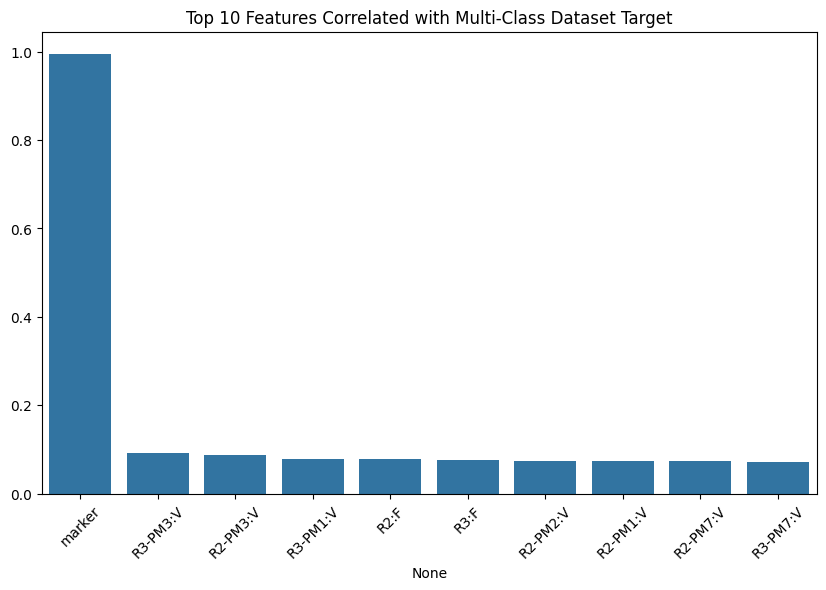

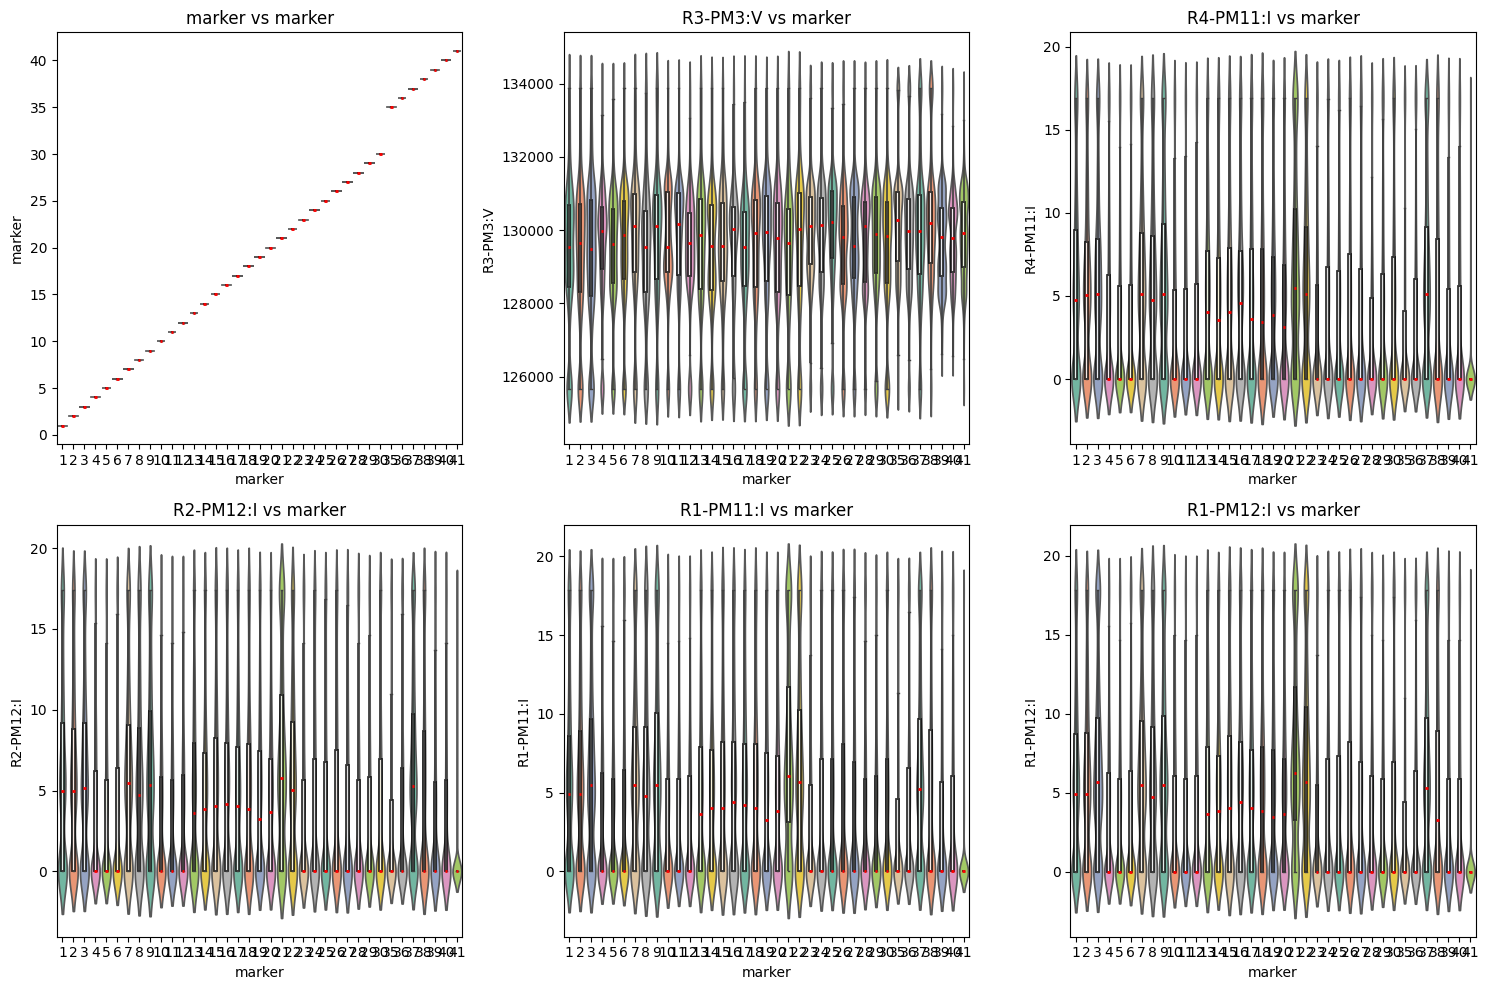


=== Multi-Class Dataset Summary ===
Number of rows: 78377
Number of columns: 130
Target column: marker
Classes: [36, 35, 41, 6, 5, 4, 37, 23, 25, 30, 38, 29, 26, 28, 24, 3, 12, 19, 11, 2, 14, 10, 40, 1, 27, 13, 20, 39, 7, 15, 16, 22, 17, 9, 8, 18, 21]
Top features correlated with target: ['marker', 'R3-PM3:V', 'R2-PM3:V', 'R3-PM1:V', 'R2:F', 'R3:F']
Next steps: feature selection, preprocessing, or model building.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

def phase1_eda(df, target_col, dataset_name):
    """
    Perform Phase 1 exploratory data analysis on a classification dataset.
    
    Parameters:
        df (pd.DataFrame): Dataset to analyze
        target_col (str): Name of the target column
        dataset_name (str): Name for the dataset (for plots and headers)
    """
    df = df.copy()
    df.columns = df.columns.str.strip()
    
    print(f"\n=== {dataset_name} Overview ===")
    print(df.info())
    print("\nDescriptive Statistics:")
    print(df.describe().T)
    
    # Encode target as numeric
    df['target_num'] = df[target_col].astype('category').cat.codes
    
    # Class distribution
    print(f"\n=== {dataset_name} Class Distribution ===")
    class_counts = df[target_col].value_counts()
    class_percent = (df[target_col].value_counts(normalize=True) * 100).round(2)
    print(class_counts)
    print("\nClass Distribution (%)")
    print(class_percent)
    
    # Plot class distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df, palette="Set2")
    plt.title(f"{dataset_name} Target Class Distribution")
    plt.show()
    
    # Correlation with target
    numeric_cols = df.select_dtypes(include='number').drop(columns=['target_num'])
    corr_target = numeric_cols.corrwith(df['target_num']).sort_values(ascending=False)
    
    print("\nTop 10 Features Correlated with Target:")
    print(corr_target.head(10))
    
    # Bar plot
    plt.figure(figsize=(10,6))
    sns.barplot(x=corr_target.head(10).index, y=corr_target.head(10).values)
    plt.xticks(rotation=45)
    plt.title(f"Top 10 Features Correlated with {dataset_name} Target")
    plt.show()
    
    # Violin + Boxplots for top 6 features
    top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
    n_cols = 3
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
    axes = axes.flatten()
    
    for i, feat in enumerate(top_features):
        sns.violinplot(
            x=target_col,
            y=feat,
            hue=target_col,
            data=df,
            ax=axes[i],
            inner=None,
            palette="Set2",
            legend=False
        )
        sns.boxplot(
            x=target_col,
            y=feat,
            data=df,
            ax=axes[i],
            width=0.25,
            showcaps=True,
            boxprops={'facecolor':'white', 'edgecolor':'black', 'linewidth':1.3, 'alpha':0.8},
            whiskerprops={'linewidth':1.2},
            medianprops={'color':'red', 'linewidth':2},
            showfliers=False
        )
        axes[i].set_title(f"{feat} vs {target_col}")
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\n=== {dataset_name} Summary ===")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    print(f"Target column: {target_col}")
    print(f"Classes: {list(class_counts.index)}")
    print(f"Top features correlated with target: {list(corr_target.head(6).index)}")
    print("Next steps: feature selection, preprocessing, or model building.")

# --- Example usage ---
binary_df = pd.read_csv("../data/merged/binary_dataset_clean.csv")
three_class_df = pd.read_csv("../data/merged/three_class_dataset_clean.csv")
multi_class_df = pd.read_csv("../data/merged/multi_class_dataset_clean.csv")

# Run Phase 1 EDA for all datasets
phase1_eda(binary_df, 'marker', "Binary Dataset")
phase1_eda(three_class_df, 'marker', "Three-Class Dataset")
phase1_eda(multi_class_df, 'marker', "Multi-Class Dataset")



=== Exploring Binary Dataset ===
Detected target column: marker

-- Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 130 entries, R1-PA1:VH to target_num
dtypes: float64(113), int64(15), int8(1), object(1)
memory usage: 77.2+ MB
None

-- Descriptive Statistics --
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459673   
...             ...            ...          ...            ...            ...   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0       0.000000     0.00

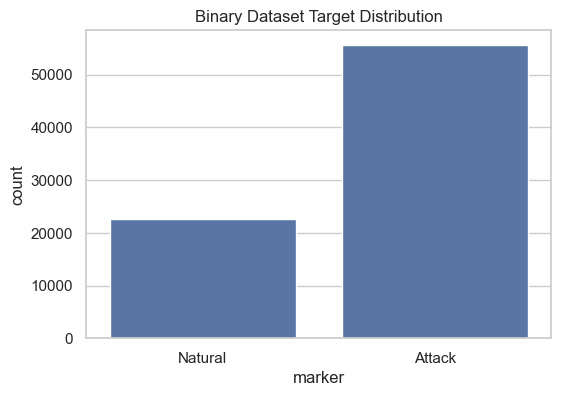

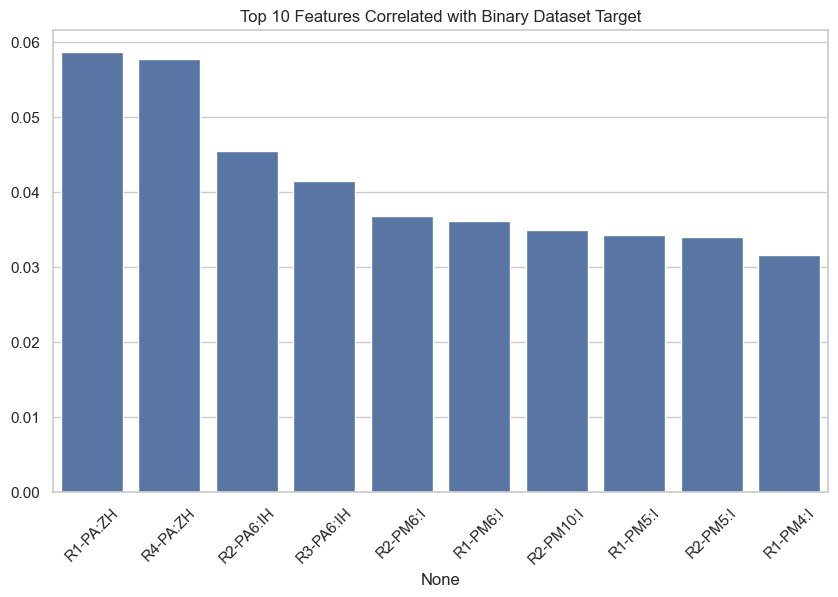

/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: F

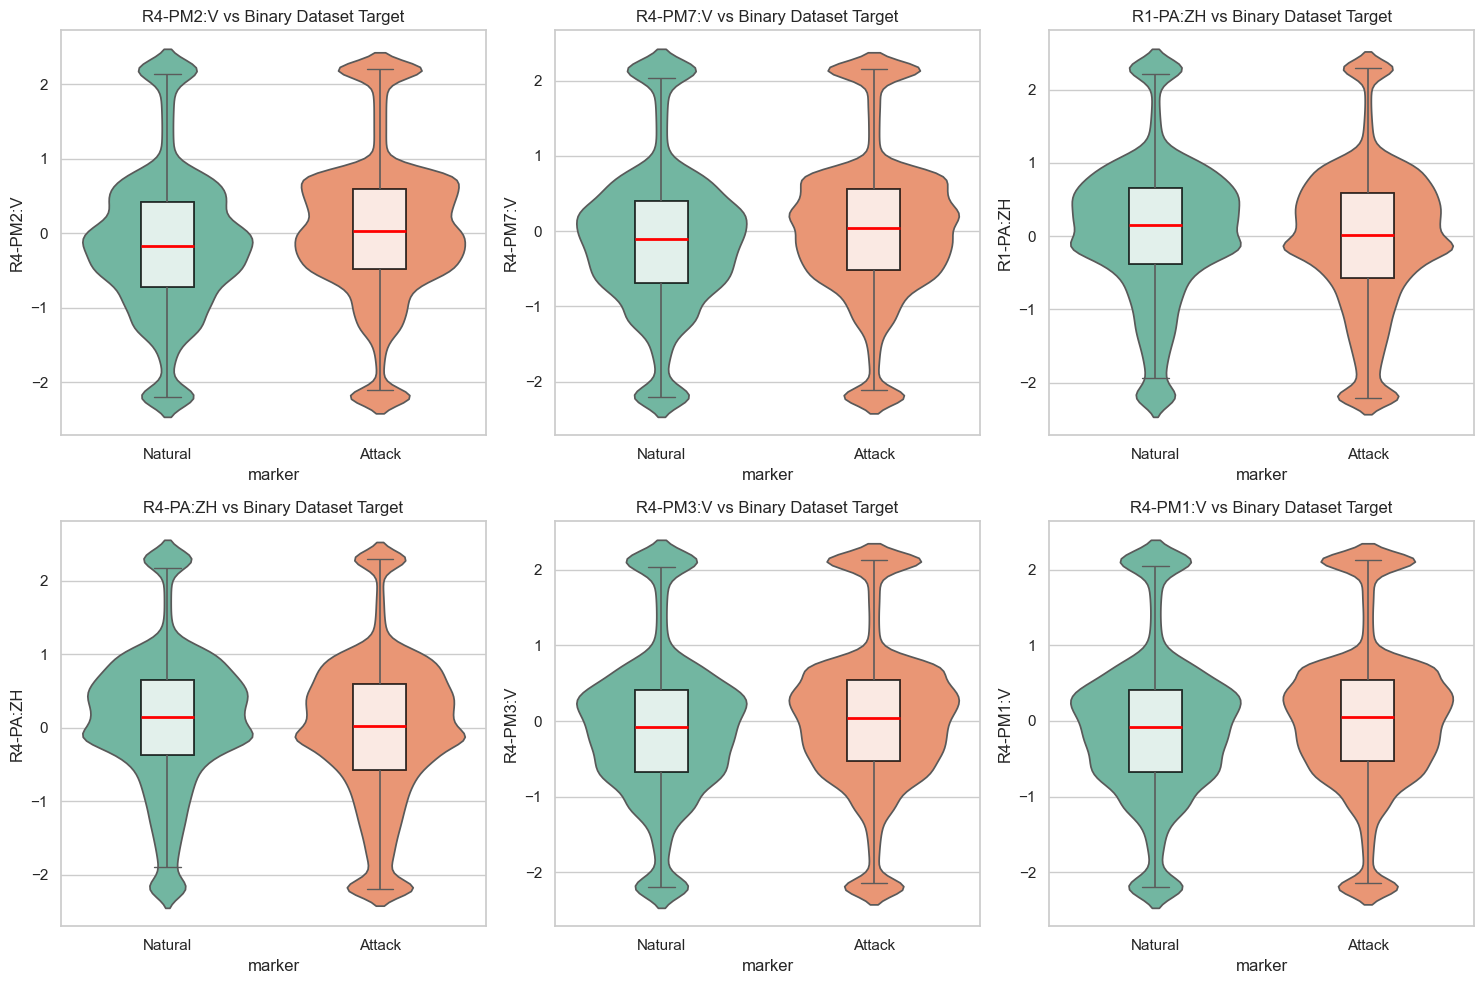


=== Exploring Three-Class Dataset ===
Detected target column: marker

-- Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 130 entries, R1-PA1:VH to target_num
dtypes: float64(113), int64(15), int8(1), object(1)
memory usage: 77.2+ MB
None

-- Descriptive Statistics --
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459673   
...             ...            ...          ...            ...            ...   
snort_log1  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log2  78377.0       0.000000    

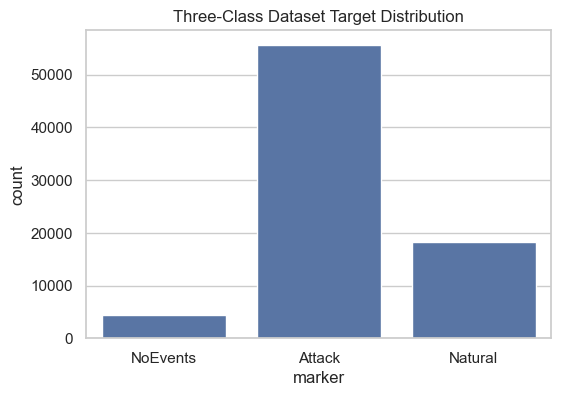

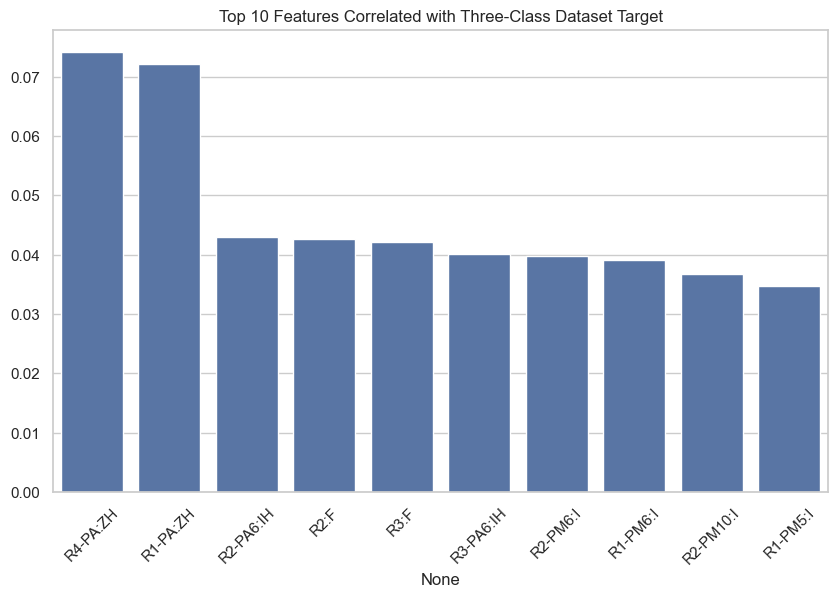

/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14405/3202313941.py:76: F

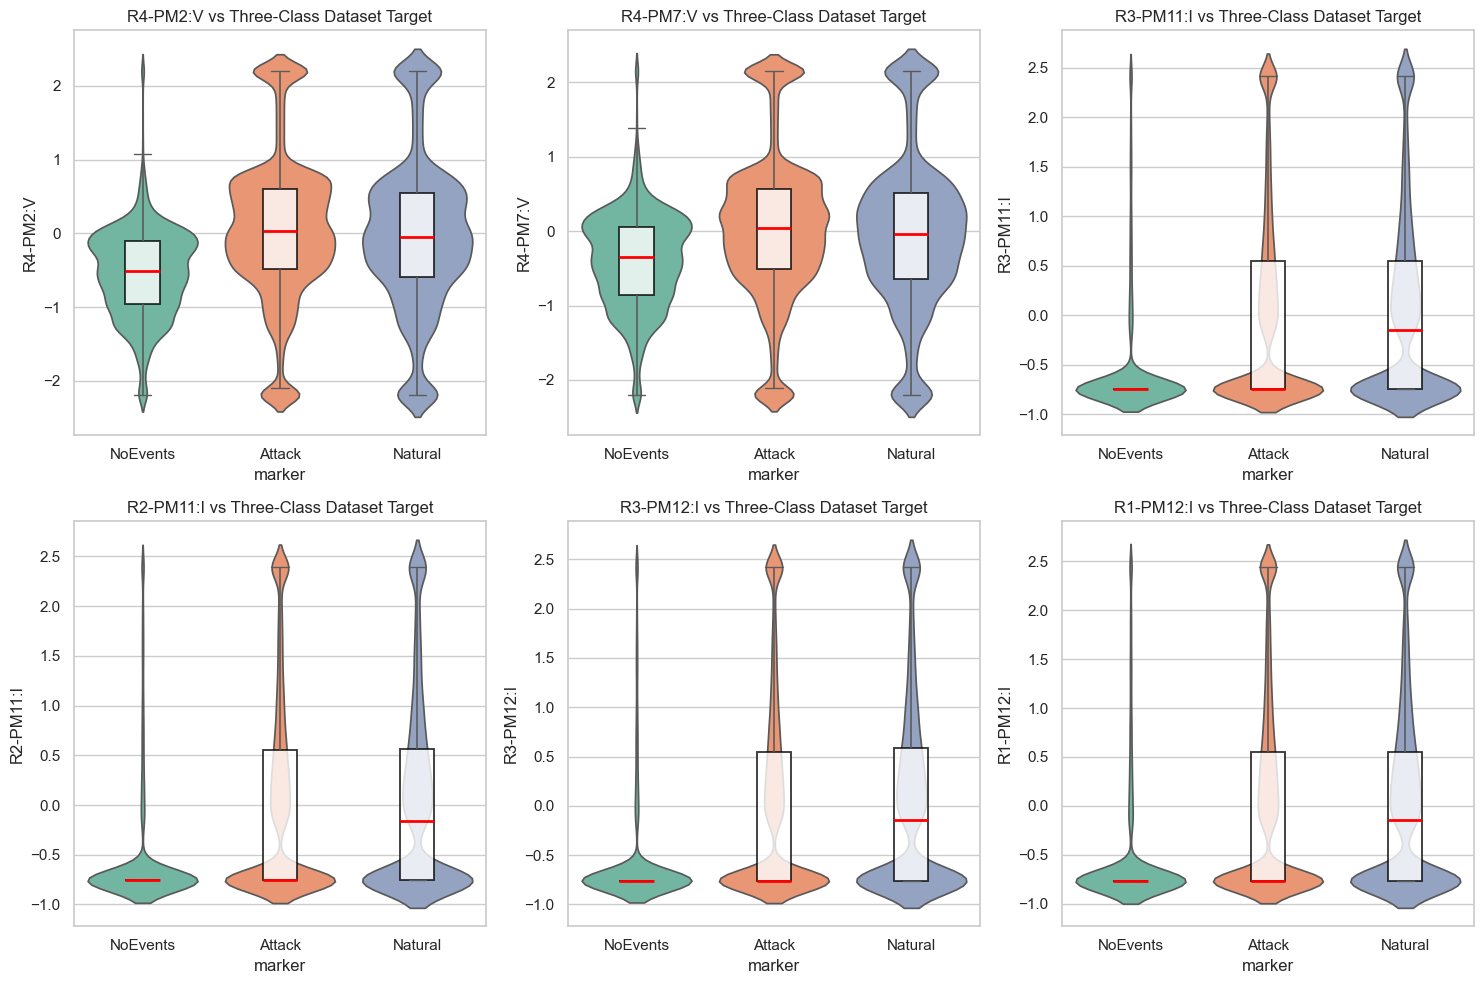


=== Exploring Multi-Class Dataset ===
Detected target column: marker

-- Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 130 entries, R1-PA1:VH to target_num
dtypes: float64(128), int64(1), int8(1)
memory usage: 77.2 MB
None

-- Descriptive Statistics --
              count           mean          std            min            25%  \
R1-PA1:VH   78377.0     -15.802424   100.876750    -179.988962    -100.416583   
R1-PM1:V    78377.0  131670.634209  1039.382656  129365.536650  131057.982300   
R1-PA2:VH   78377.0       2.175196   111.743169    -179.994691    -102.129727   
R1-PM2:V    78377.0  131361.012902  1070.855517  129001.974200  130732.029800   
R1-PA3:VH   78377.0       6.834315    97.065063    -179.994691     -69.459674   
...             ...            ...          ...            ...            ...   
snort_log2  78377.0       0.000000     0.000000       0.000000       0.000000   
snort_log3  78377.0       0.000000     0.000000    

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [32]:
# =====================================
# Complete Data Exploration Workflow
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set(style="whitegrid")

# -------------------------------
# Helper function for exploration
# -------------------------------
def explore_dataset(df, dataset_name="Dataset"):
    print(f"\n=== Exploring {dataset_name} ===")
    
    # Strip column names
    df.columns = df.columns.str.strip()
    
    # Detect target column automatically
    possible_targets = [col for col in df.columns if 'target' in col.lower() or 'marker' in col.lower()]
    if len(possible_targets) == 0:
        raise ValueError(f"No target column found in {dataset_name}")
    target_col = possible_targets[0]
    print(f"Detected target column: {target_col}")
    
    # Encode target
    df['target_num'] = df[target_col].astype('category').cat.codes
    
    # Dataset overview
    print("\n-- Info --")
    print(df.info())
    print("\n-- Descriptive Statistics --")
    print(df.describe().T)
    
    # Handle missing values by median (optional)
    numeric_cols = df.select_dtypes(include='number').drop(columns=['target_num'])
    df[numeric_cols.columns] = df[numeric_cols.columns].fillna(df[numeric_cols.columns].median())
    
    # Standardize numeric features
    scaler = StandardScaler()
    df[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
    print("✅ Numeric features standardized (mean=0, std=1)")
    
    # Class distribution
    print("\n-- Class Distribution --")
    print(df[target_col].value_counts())
    print(df[target_col].value_counts(normalize=True) * 100)
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df)
    plt.title(f"{dataset_name} Target Distribution")
    plt.show()
    
    # Correlation with target
    corr_target = df[numeric_cols.columns].corrwith(df['target_num']).sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=corr_target.head(10).index, y=corr_target.head(10).values)
    plt.xticks(rotation=45)
    plt.title(f"Top 10 Features Correlated with {dataset_name} Target")
    plt.show()
    
    # Violin + Boxplots for top 6 features
    top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
    n_cols = 3
    n_rows = (len(top_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for i, feat in enumerate(top_features):
        sns.violinplot(
            x=target_col, y=feat, data=df,
            inner=None, palette="Set2", ax=axes[i]
        )
        sns.boxplot(
            x=target_col, y=feat, data=df,
            width=0.25, showcaps=True,
            boxprops={'facecolor':'white','edgecolor':'black','linewidth':1.3,'alpha':0.8},
            whiskerprops={'linewidth':1.2},
            medianprops={'color':'red','linewidth':2},
            showfliers=False, ax=axes[i]
        )
        axes[i].set_title(f"{feat} vs {dataset_name} Target")
    
    # Hide unused axes
    for j in range(len(top_features), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return df, corr_target

# -------------------------------
# 1. Binary Dataset
# -------------------------------
binary_df = pd.read_csv("../data/merged/binary_dataset_clean.csv")
binary_df, corr_binary = explore_dataset(binary_df, "Binary Dataset")

# -------------------------------
# 2. Three-Class Dataset
# -------------------------------
three_class_df = pd.read_csv("../data/merged/three_class_dataset_clean.csv")
three_class_df, corr_three = explore_dataset(three_class_df, "Three-Class Dataset")

# -------------------------------
# 3. Multi-Class Dataset
# -------------------------------
multi_class_df = pd.read_csv("../data/merged/multi_class_dataset_clean.csv")
multi_class_df, corr_multi = explore_dataset(multi_class_df, "Multi-Class Dataset")

# -------------------------------
# Comparison Across Datasets
# -------------------------------
# Combine top correlations
compare_corr = pd.DataFrame({
    'Binary': corr_binary.head(10),
    'Three-Class': corr_three.head(10),
    'Multi-Class': corr_multi.head(10)
}).fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(compare_corr, annot=True, cmap='coolwarm')
plt.title("Top Feature Correlations Across Datasets")
plt.show()
